<h1>MonReader: Single Frame Modelling (SFM): Model Training 2

<h3>Continuing SFM model training

In [1]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
TRAIN_DATA_DIR = RAW_DATA_DIR / "training"
TEST_DATA_DIR = RAW_DATA_DIR / "testing"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
SFM_DATA_DIR = PROCESSED_DATA_DIR / "sfm"

MODELS_DIR = PROJ_ROOT / "models"
SFM_MODELS_DIR = MODELS_DIR / "sfm"

In [2]:
# Base
import os
import pickle
import numpy as np
import pandas as pd

# Custom
from mrp_functions import *

Load the data, shuffle it, then create validation sets, using the custom functions from the previous notebook for repeatability:

In [3]:
pkl_data = load_pickle_data(SFM_DATA_DIR)

Loaded 4 pickle files:
['X_test', 'X_train', 'y_test', 'y_train']


In [4]:
X_train = pkl_data['X_train']
y_train = pkl_data['y_train']
X_test = pkl_data['X_test']
y_test = pkl_data['y_test']

In [5]:
X_train, y_train = shuffle_training_data(X_train, y_train)
X_train, X_val, y_train, y_val = create_validation_set(X_train, y_train)

In [6]:
# Inspect data: 
print("Training Data:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Class distribution: {np.bincount(y_train)}")

print("\nValidation Data:")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_val shape: {y_val.shape}")
print(f"  Class distribution: {np.bincount(y_val)}")

print("\nTest Data:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Class distribution: {np.bincount(y_test)}")

# Inspect pixel value ranges
print("\nPixel value ranges:")
print(f"  X_train: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"  X_val: [{X_val.min():.4f}, {X_val.max():.4f}]")
print(f"  X_test: [{X_test.min():.4f}, {X_test.max():.4f}]")

Training Data:
  X_train shape: (1913, 480, 270, 1)
  y_train shape: (1913,)
  Class distribution: [984 929]

Validation Data:
  X_val shape: (479, 480, 270, 1)
  y_val shape: (479,)
  Class distribution: [246 233]

Test Data:
  X_test shape: (597, 480, 270, 1)
  y_test shape: (597,)
  Class distribution: [307 290]

Pixel value ranges:
  X_train: [0.0000, 1.0000]
  X_val: [0.0000, 0.9961]
  X_test: [0.0000, 1.0000]


**'model_1'** from the last notebook had lots of overfitting as shown in the training vs validation loss curves divergence characteristics (see copy below). It's important to address this now.

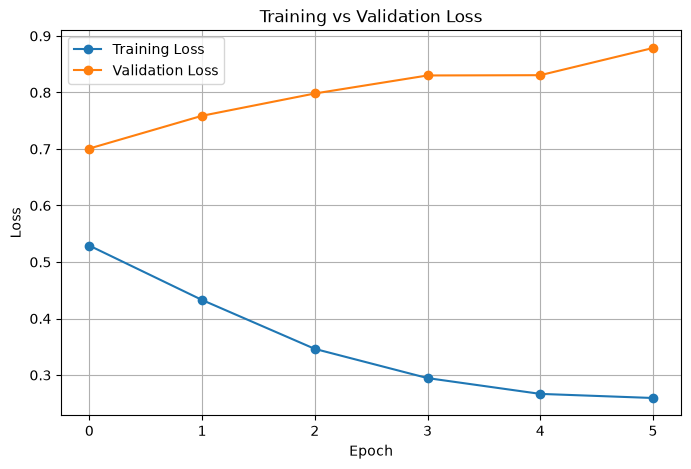

Let's create a new model with tweaks to address this overfitting:

Things to consider when creating the new model:

- **The output layer and loss don't match the problem cleanly**: Using Dense(2, sigmoid), with binary_crossentropy as the loss function, the targets are OneHot encoded despite the fact that we are dealing with a binary problem where the classes are mutually exclusive. Better to treat as binary rather than one hot i.e. [0,1] and [1,0]. Use 0 and 1. May be better to use: Dense(1, activation="sigmoid") with 'binary_crossentropy' for the loss.

- The very immediate overfitting shown in the loss curve is strange. **I don't think it is a pre-processing error** as the same steps are applied to both the train and test set, then randomisation of the train set occurs, followed by a random vaildation split. **Perhaps data augmentation could prove useful.**

- **Can a single frame from a clip show whether a page is being flipped, or are other frames of the same clip required to make the distinction?** Let's inspect some of the images to see if a human could make the distinction.

Quick inspection:

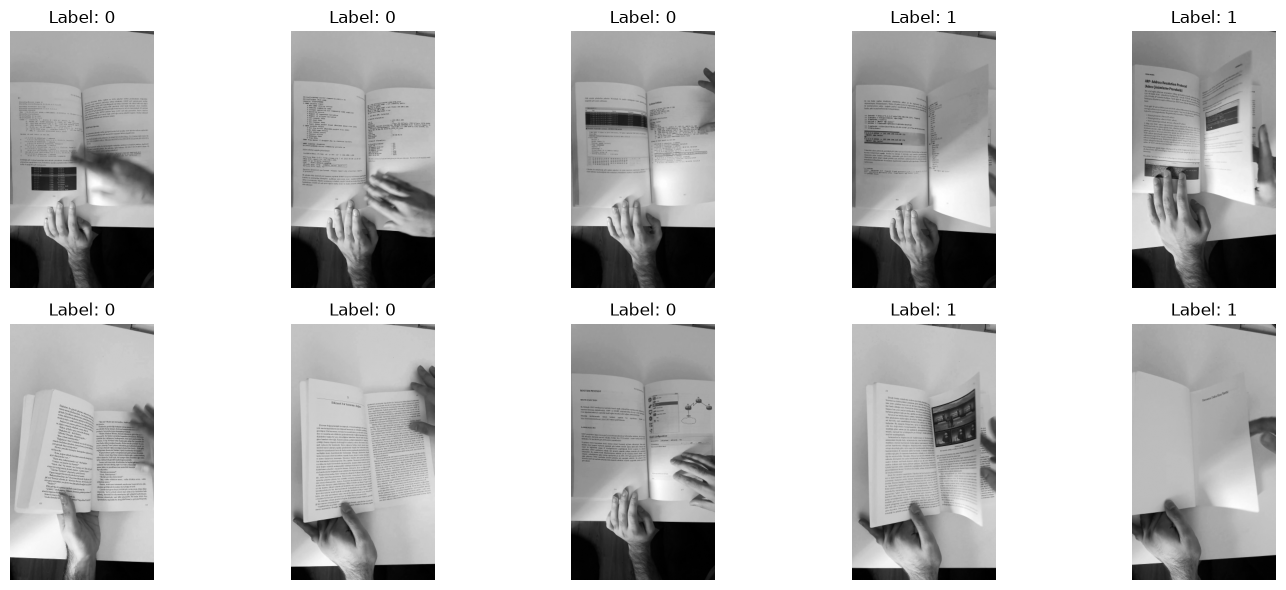

In [7]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = random.sample(range(len(X_train)), 10)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx].squeeze(), cmap='gray')
    ax.set_title(f"Label: {y_train[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Labels: 0 = notflip, 1 = flip.

As seen in the images there are obvious instances where a page flip is observed and labelled as such. The things that makes a page flip distinct in the images is a *single page mid motion and at-an-angle*. There are a few instances where the way that the human is holding the book at an angle regardless of label which the model could see as a page flip. The key is that the page flip is near the centre of the image and sometimes involves a small covering of the human's hand(s).

**At this stage I think that there is enough information at a single frame level to make a distinction**, we just need to create a model that can do so.

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
import matplotlib.pyplot as plt

In [9]:
train_model_2 = False

In [10]:
if train_model_2 == True:
    # This model looks simpler
    model_2 = Sequential([
        Conv2D(32,3,padding="same",activation="relu",input_shape=X_train.shape[1:]),
        BatchNormalization(),

        Conv2D(32, 3, activation="relu"),
        MaxPooling2D(),
        Dropout(0.2),

        Conv2D(128, 3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.2),

        GlobalAveragePooling2D(),

        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.3), # Increased slightly

        Dense(1, activation="sigmoid") # Changed as mentioned in the first bullet point above.
    ])

    model_2.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=["accuracy",
                     tf.keras.metrics.Precision(name="precision"),
                     tf.keras.metrics.Recall(name="recall"),
                     tf.keras.metrics.AUC(name="auc")]
            )

    model_2.summary()

    early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=2
            )
    
    # Removed the 'to_categorical' parts as we have implemented Dense(1) above.

    trained_model_2 = model_2.fit(
            X_train,
            y_train,
            batch_size=64, # Batch size can affect training
            epochs=10,
            shuffle=True,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping]
        )
    

Loaded model from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2.keras'
Loaded history from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2_history.pkl'


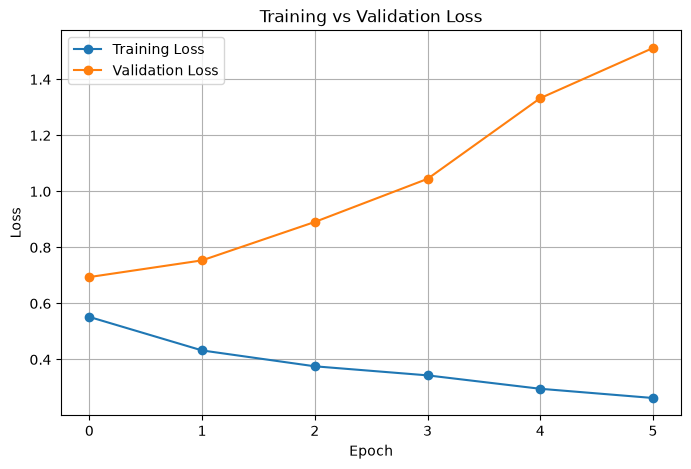

In [11]:
if train_model_2 == False:
    trained_model_2,trained_model_2_history =  load_model("model_2", SFM_MODELS_DIR)
    plot_training_history(trained_model_2_history, metric='loss')
else:
    trained_model_2_history = trained_model_2.history
    plot_training_history(trained_model_2_history, metric='loss')

Make some predictions:

Test set evaluation:
  loss: 0.6933549046516418
  compile_metrics: 0.4857621490955353

Classification Report:
              precision    recall  f1-score   support

     notflip       0.00      0.00      0.00       307
        flip       0.49      1.00      0.65       290

    accuracy                           0.49       597
   macro avg       0.24      0.50      0.33       597
weighted avg       0.24      0.49      0.32       597

Macro F1-score: 0.3269


c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


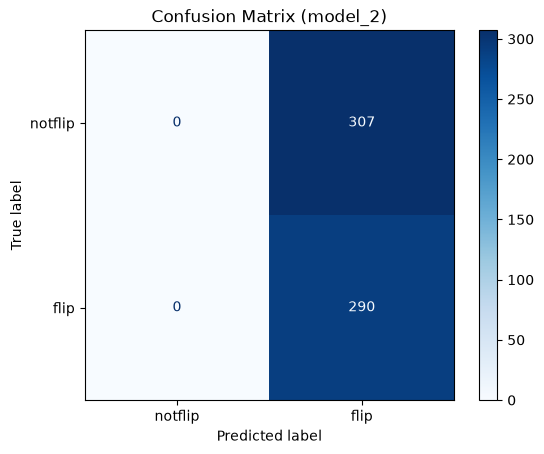

In [12]:
from mrp_functions import evaluate_model

# Logic regarding re-execution without retraining
model_2_to_eval = model_2 if train_model_2 else trained_model_2

eval_results = evaluate_model(
    model_2_to_eval,
    X_test,
    y_test,
    class_names=('notflip', 'flip'),
    plot_name="model_2"
)

Exact same confusion matrix as model_1. 

Save the model:

In [13]:
if train_model_2 == True:
    model_path = SFM_MODELS_DIR / 'model_2' # Don't worry about .pkl or .keras at the end, the function will take care of it.
    save_model(model_path, model_2, model_2.history)

<h3>Image Manipulation to Enhance Image Features

We could apply data augmentation to the data to introduce more feature variance between images which could in theory reduce overfitting.

Another thing we could do is make page/hand/text edges in the images more distinct via modifying the brightness and contrast of the images before data augmentation?

Let's take an example image and apply some enhncements to make the features more distinct:

In [14]:
eg_im = X_train[0]

In [15]:
import cv2

# Single image function with adjustable parameters
def enhance_image(image,gamma=0.9,clahe_clip=2.0,clahe_grid=(8, 8),sharpen_amount=0.5):
    """
    Enhance a normalized grayscale image.

    Parameters
    ----------
    image : np.ndarray
        Image of shape (H, W, 1), expected range [0, 1].

    gamma : float
        < 1 brightens image.
        > 1 darkens image.

    CLAHE — Contrast Limited Adaptive Histogram Equalization

    clahe_clip : float
        Strength of local contrast enhancement.

    clahe_grid : tuple
        Size of local regions used by CLAHE.

    sharpen_amount : float
        Strength of unsharp masking.

    Returns
    -------
    np.ndarray
        Enhanced float32 image in range [0, 1].
    """

    # Remove final channel dimension
    img = np.squeeze(image)
    # Convert [0,1] float -> [0,255] uint8 for OpenCV
    img = np.clip(img * 255, 0, 255).astype(np.uint8)

    
    # 1. Gamma / exposure
    img_float = img.astype(np.float32) / 255.0
    img_float = np.power(img_float, gamma)
    img = np.clip(img_float * 255,0,255).astype(np.uint8)

    # 2. Local contrast: CLAHE
    clahe = cv2.createCLAHE(clipLimit=clahe_clip,tileGridSize=clahe_grid)
    img = clahe.apply(img)

    # 3. Mild sharpening
    blurred = cv2.GaussianBlur(img,(0, 0),sigmaX=1.0)
    img = cv2.addWeighted(img,1 + sharpen_amount,blurred,-sharpen_amount,0)

    # Convert back to float32 [0,1]
    img = img.astype(np.float32) / 255.0

    return img[..., np.newaxis]

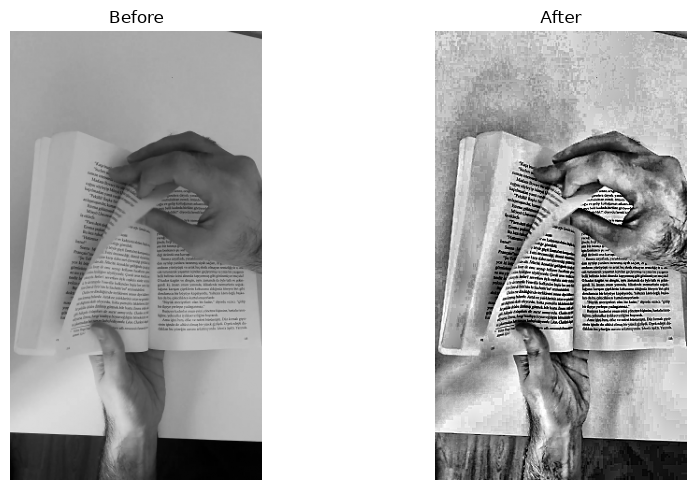

In [28]:
# Enhancement parameters:
gamma = 0.9
clahe_clip = 10.0
clahe_grid = (16,16)
sharpness = 1.0

# Apply enhancements:
mod_eg_im = enhance_image(image = eg_im, gamma=gamma, clahe_clip=clahe_clip, clahe_grid=clahe_grid, sharpen_amount=sharpness)


# Display:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(eg_im.squeeze(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Before")
axes[0].axis("off")

axes[1].imshow(mod_eg_im.squeeze(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("After")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [29]:
print(f"Before: {eg_im.shape}")
print(f"After: {mod_eg_im.shape}")

Before: (480, 270, 1)
After: (480, 270, 1)


In [30]:
# Function to modify whole set:

def enhance_dataset(X, **kwargs):
    return np.stack([
        enhance_image(image, **kwargs)
        for image in X
    ]).astype(np.float32)

In [31]:
# Load 'fresh' data:

pkl_data = load_pickle_data(SFM_DATA_DIR)

X_train = pkl_data['X_train']
y_train = pkl_data['y_train']
X_test = pkl_data['X_test']
y_test = pkl_data['y_test']

X_train, y_train = shuffle_training_data(X_train, y_train)

Loaded 4 pickle files:
['X_test', 'X_train', 'y_test', 'y_train']


In [33]:
# Apply:
enhancement_params = {
    "gamma": 0.9,
    "clahe_clip": 10.0,
    "clahe_grid": (16, 16),
    "sharpen_amount": 1.0,
}

X_train_enh = enhance_dataset(X_train, **enhancement_params)
X_test_enh = enhance_dataset(X_test, **enhancement_params)

In [34]:
X_train, X_val, y_train, y_val = create_validation_set(X_train_enh, y_train)

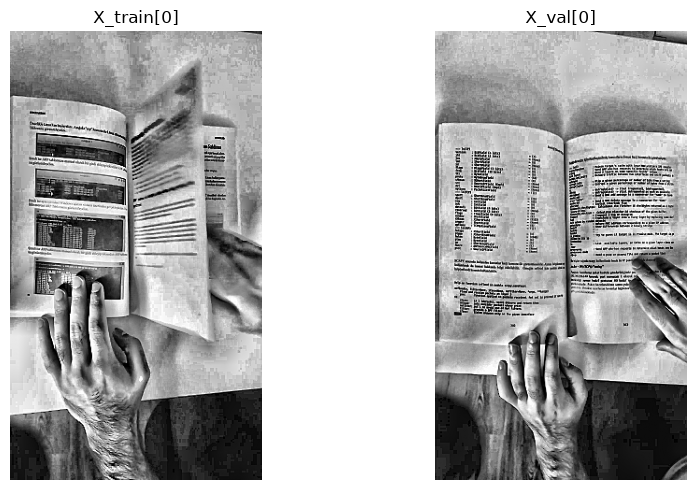

In [37]:
# Display:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(X_train[1].squeeze(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("X_train[0]")
axes[0].axis("off")

axes[1].imshow(X_val[0].squeeze(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("X_val[0]")
axes[1].axis("off")

plt.tight_layout()
plt.show()

<h3>Train 'model_2' Replica on the Enhanced Images (model_2_1)

In [ ]:
train_model_2_1 = False

In [39]:
if train_model_2_1 == True:
    # This model looks simpler
    model_2_1 = Sequential([
        Conv2D(32,3,padding="same",activation="relu",input_shape=X_train.shape[1:]),
        BatchNormalization(),

        Conv2D(32, 3, activation="relu"),
        MaxPooling2D(),
        Dropout(0.2),

        Conv2D(128, 3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.2),

        GlobalAveragePooling2D(),

        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.3), # Increased slightly

        Dense(1, activation="sigmoid") # Changed as mentioned in the first bullet point above.
    ])

    model_2_1.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=["accuracy",
                     tf.keras.metrics.Precision(name="precision"),
                     tf.keras.metrics.Recall(name="recall"),
                     tf.keras.metrics.AUC(name="auc")]
            )

    model_2_1.summary()

    early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=2
            )
    
    # Removed the 'to_categorical' parts as we have implemented Dense(1) above.

    trained_model_2_1 = model_2_1.fit(
            X_train,
            y_train,
            batch_size=64, # Batch size can affect training
            epochs=10,
            shuffle=True,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping]
        )
    

c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 270, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 480, 270, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 478, 268, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 239, 134, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 239, 134, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 239, 134, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 239, 134, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 119, 67, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 119, 67, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,489 (201.13 KB)

 Trainable params: 51,105 (199.63 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 171s 6s/step - accuracy: 0.7141 - auc: 0.7734 - loss: 0.5771 - precision: 0.7045 - recall: 0.7083 - val_accuracy: 0.4864 - val_auc: 0.4523 - val_loss: 0.7022 - val_precision: 0.4864 - val_recall: 1.0000
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 173s 6s/step - accuracy: 0.8217 - auc: 0.8969 - loss: 0.4076 - precision: 0.8534 - recall: 0.7643 - val_accuracy: 0.4864 - val_auc: 0.5874 - val_loss: 0.7773 - val_precision: 0.4864 - val_recall: 1.0000
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 174s 6s/step - accuracy: 0.8604 - auc: 0.9328 - loss: 0.3357 - precision: 0.9056 - recall: 0.7955 - val_accuracy: 0.4864 - val_auc: 0.5617 - val_loss: 0.9399 - val_precision: 0.4864 - val_recall: 1.0000
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 166s 6s/step - accuracy: 0.8766 - auc: 0.9393 - loss: 0.3131 - precision: 0.9130 - recall: 0.8245 - val_accuracy: 0.4864 - val_auc: 0.5460 - val_loss: 1.1630 - val_precision: 0.4864 - val_recall: 1.0000
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━

In [47]:
if train_model_2_1 == True:
    model_path = SFM_MODELS_DIR / 'model_2_1'
    save_model(model_path, model_2_1, model_2_1.history)

Saved model to 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2_1.keras'
Model size: 0.65 MB
History size: 0.0007 MB
Saved history to 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2_1_history.pkl'


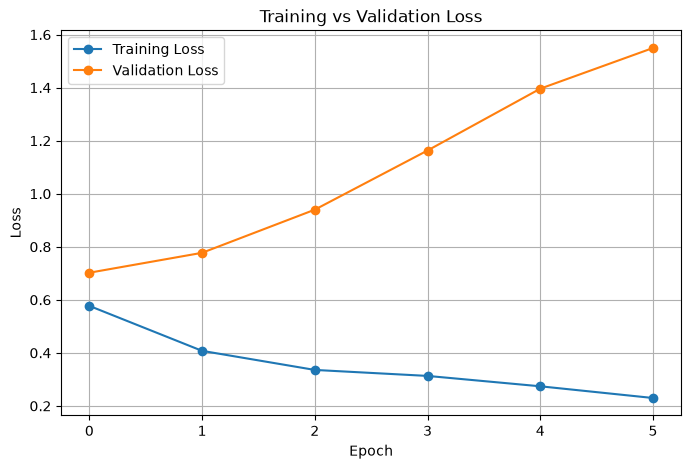

In [40]:
if train_model_2_1 == False:
    trained_model_2_1,trained_model_2_1_history =  load_model("model_2_1", SFM_MODELS_DIR)
    plot_training_history(trained_model_2_1_history, metric='loss')
else:
    trained_model_2_1_history = trained_model_2_1.history
    plot_training_history(trained_model_2_1_history, metric='loss')

Test set evaluation:
  loss: 0.701846718788147
  compile_metrics: 0.4857621490955353

Classification Report:
              precision    recall  f1-score   support

     notflip       0.00      0.00      0.00       307
        flip       0.49      1.00      0.65       290

    accuracy                           0.49       597
   macro avg       0.24      0.50      0.33       597
weighted avg       0.24      0.49      0.32       597

Macro F1-score: 0.3269


c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


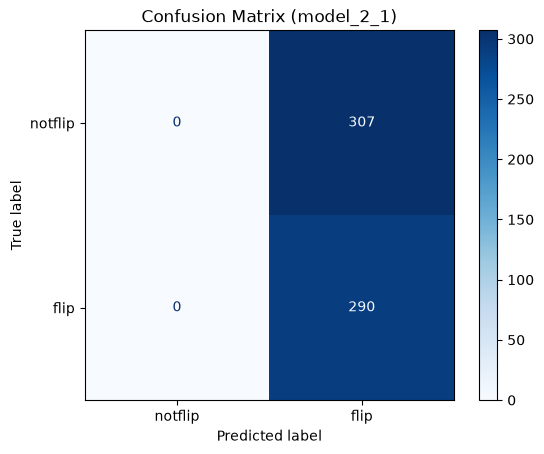

In [46]:
model_2_1_to_eval = model_2_1 if train_model_2_1 else trained_model_2_1

# Guard against accidentally passing the training History object
if isinstance(model_2_1_to_eval, tf.keras.callbacks.History):
    model_2_1_to_eval = model_2_1

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test_enh, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    model_2_1_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="model_2_1"
)

Exactly the same. May need to consider implementing data augmentation to create variance in different frames of the same clip

In [48]:
if train_model_2_1 == True:
    model_path = SFM_MODELS_DIR / 'model_2_1'
    save_model(model_path, model_2_1, model_2_1.history)

Saved model to 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2_1.keras'
Model size: 0.65 MB
History size: 0.0007 MB
Saved history to 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2_1_history.pkl'


<h3> Data Augmentation

Types of data augmentation to apply:
